<a href="https://colab.research.google.com/github/KenStevens2/MomoStream/blob/main/MomoStream.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import dependencies and logging
import pandas as pd
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import Image, display
import ipywidgets as widgets
import requests
import logging
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)
pd.set_option("display.max_colwidt", 200)
sns.set(style="whitegrid")


In [ ]:
#Import and view dataset
df = pd.read_csv("animes.csv")
print("Shape:", df.shape)
df.head()


Shape: (1255, 41)


,anime,anime_url,anime_img,episodes,votes,weight,rate,rate_1,rate_2,rate_3,...,genre_romance,genre_sci-fi,genre_seinen,genre_sgdrama,genre_shojo,genre_shonen,genre_slice of life,genre_sports,genre_supernatural,genre_thriller
0,Naruto Shippuuden,https://www.crunchyroll.com/naruto-shippuden,https://img1.ak.crunchyroll.com/i/spire4/1c1df98707aa0f22aa54342af725e48a1491245343_full.jpg,500,48518,233346,4.81,1111,275,817,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Shugo Chara,https://www.crunchyroll.com/shugo-chara,https://img1.ak.crunchyroll.com/i/spire1/7c0c0cd3958894b2dafc740ba847e4f11279141777_full.jpg,51,33688,163641,4.86,503,104,438,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,BLEACH,https://www.crunchyroll.com/bleach,https://img1.ak.crunchyroll.com/i/spire2/52edb7a843abacb4ff0f642c8eda14401325114125_full.jpg,366,23900,115445,4.83,391,98,370,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Naruto,https://www.crunchyroll.com/naruto,https://img1.ak.crunchyroll.com/i/spire2/0145388e3ecfdb5a63ce1e9feaeef44a1279141923_full.jpg,220,16613,79667,4.80,456,64,282,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Skip Beat!,https://www.crunchyroll.com/skip-beat,https://img1.ak.crunchyroll.com/i/spire3/4bbe3a679c7365d16dd49c9d78ae992e1279142023_full.jpg,0,15011,73683,4.91,98,20,112,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#Clean dataset

genre_columns = [c for c in df.columns if c.startswith("genre_")]
all_genres = [c.replace("genre_", "") for c in genre_columns]
print("Number of genres:", len(genre_columns))
print("Test genres:", all_genres[:29])
x_genres = df[genre_columns].values

Number of genres: 29
Test genres: ['action', 'adventure', 'comedy', 'drama', 'family', 'fantasy', 'food', 'harem', 'historical', 'horror', 'idols', 'isekai', 'jdrama', 'magical girls', 'martial arts', 'mecha', 'music', 'mystery', 'post-apocalyptic', 'romance', 'sci-fi', 'seinen', 'sgdrama', 'shojo', 'shonen', 'slice of life', 'sports', 'supernatural', 'thriller']


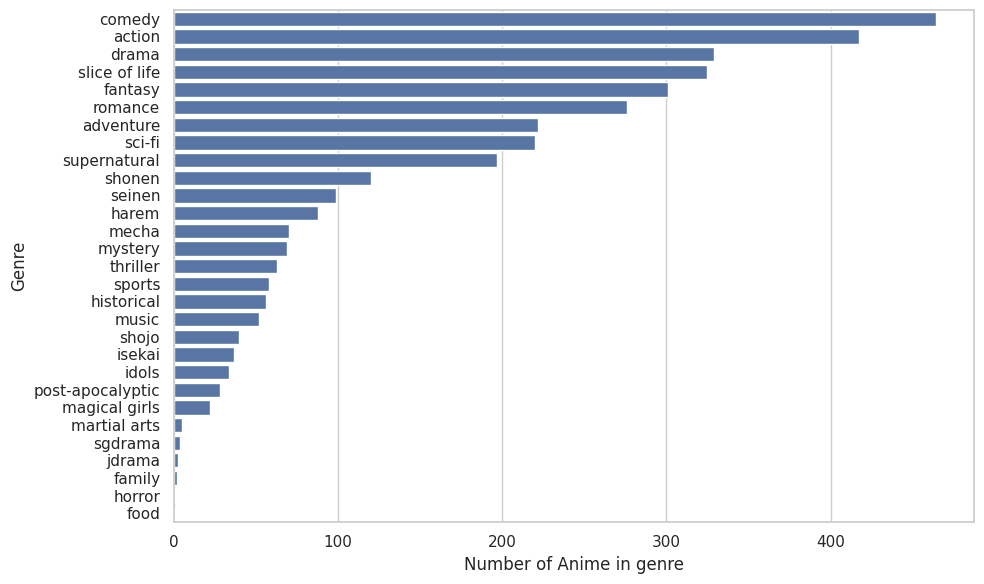

In [ ]:
# Most Popular Genres
genre_counts = df[genre_columns].sum().sort_values(ascending=False)
genre_counts.index = [g.replace("genre_", "") for g in genre_counts.index]
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values[:29], y=genre_counts.index[:29], orient="h")
plt.xlabel("Number of Anime in genre")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

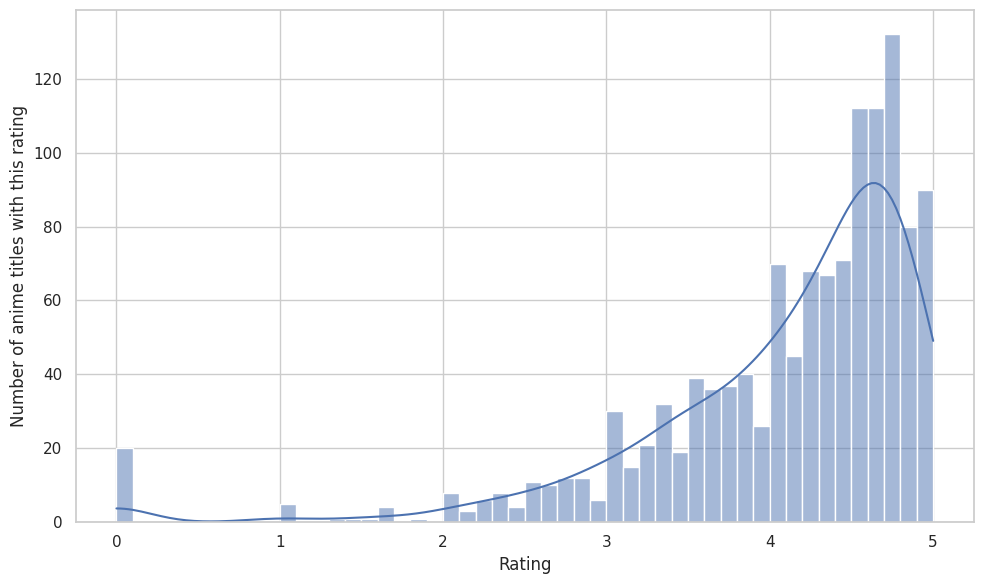

In [ ]:
# Rating Distribution Visualization
plt.figure(figsize=(10, 6))
sns.histplot(df["rate"].dropna(), bins=50, kde=True)
plt.xlabel("Rating")
plt.ylabel("Number of anime titles with this rating")
plt.tight_layout()
plt.show()

In [ ]:
#Genre based recommendation system

def recommend_by_genres(selected_genres, top_n=10):
  selected_genres = [g.strip().lower() for g in selected_genres]

  invalid = [g for g in selected_genres if g not in all_genres]
  if invalid:
    raise ValueError(f"Invalid genres: {', '.join(invalid)}")

  ideal_vec = np.zeros(len(all_genres))
  for g in selected_genres:
    idx = all_genres.index(g)
    ideal_vec[idx] = 1

  similarity_score = cosine_similarity(ideal_vec.reshape(1, -1), x_genres)[0]

  def_temp = df.copy()
  def_temp["similarity"] = similarity_score
  def_temp = def_temp[def_temp["similarity"] > 0]

  def_rec = def_temp.sort_values(
      by=["similarity", "rate"], ascending=[False, False]
      )

  return def_rec.head(top_n)

In [ ]:
#Recommendation Evaluation

def evaluate_recommendations(recs_df, rating_weight=.4, similarity_weight=0.6):
  if recs_df.empty:
    return {"error": "No recommendations available."}
  average_rating = recs_df["rate"].mean()
  average_similarity = recs_df["similarity"].mean()
  rating_norm = (average_rating - 1) / 4
  overall_score = (rating_norm * rating_weight) + (average_similarity * similarity_weight)
  percent_score = round(overall_score * 100, 2)
  logging.info(f"Overall Recommendation Score: {percent_score}%")
  return f"{percent_score}%"



In [ ]:
#Create card layouts

def display_cards(recs_df):
  html = "<div style='display:flex; flex-wrap:wrap;'>"

  for _, row in recs_df.iterrows():
    title = row["anime"]
    img_url = row["anime_img"]
    rating = row["rate"]
    similarity = round(row["similarity"], 3)

    try:
      headers = {"User-Agent": "Mozilla/5.0"}
      response = requests.get(img_url, headers=headers)
      if response.status_code == 200:
        img_data = f"<img src='{img_url}' style='width:200px; height:280px; object-fit:cover; boarder-radius:6px;'>"
      else:
        img_data = f"<div style='width:200px; height:280px; background:#444; boarder-radius:6px;'></div>"
    except:
      img_data = f"<div style='width:200px; height:280px; background:#444; boarder-radius:6px;'></div>"

    card = f"""
    <div style="
      width:220px;
      margin:10px;
      padding:10px;
      border-radius:6px;
      background:#1e1e1e;
      color: orange;
      box-shadow: 0 4px 10px rgba(0,0,0,0.4);
      text-align: center;
    ">
      {img_data}
      <h4 style="margin:10px 0 5px 0; font-size:16px;">{title}</h4>
      <p style="margin:0; font-size:14px;">Rating: {rating}</p>
      <p style="margin:0; font-size:14px;">Similarity: {similarity}</p>
    </div>
    """
    html += card

  html += "</div>"
  display(widgets.HTML(html))



In [ ]:
#Main Dashboard

genre_buttons = [
    widgets.ToggleButton(description=g, value=False, layout=widgets.Layout(width="150px"))
     for g in all_genres
]

rows =[]
for i in range(0, len(genre_buttons), 6):
  rows.append(widgets.HBox(genre_buttons[i:i+6]))
genre_box = widgets.VBox(rows)

run_button = widgets.Button(description="Get Recommendations", layout=widgets.Layout(width="200px"), button_style=("success"))
output = widgets.Output()

def on_click_run(b):
  output.clear_output()
  selected = [btn.description for btn in genre_buttons if btn.value]
  with output:
    if len(selected) != 3:
      display(widgets.HTML("<h3>Please select 3 genres.</h3>"))
      return
    display(widgets.HTML(f"<h3>Recommendations in : {',  '.join(selected)}</h3>"))
    selected_genres = selected[:3]

    try:
      recs = recommend_by_genres(selected_genres, top_n=10)
    except Exception as e:
      print(e)
      return

    display_cards(recs)
    overall_score = evaluate_recommendations(recs)
    display(widgets.HTML(f"<h3>Overall Recommendation Score: {overall_score}</h3>"))

run_button.on_click(on_click_run)

display(widgets.HTML("<h3>Select genres 3 from the list below.</h3>"))
display(genre_box, run_button, output)

HTML(value='<h3>Select genres 3 from the list below.</h3>')

Button(button_style='success', description='Get Recommendations', layout=Layout(width='200px'), style=ButtonSt…

Output()

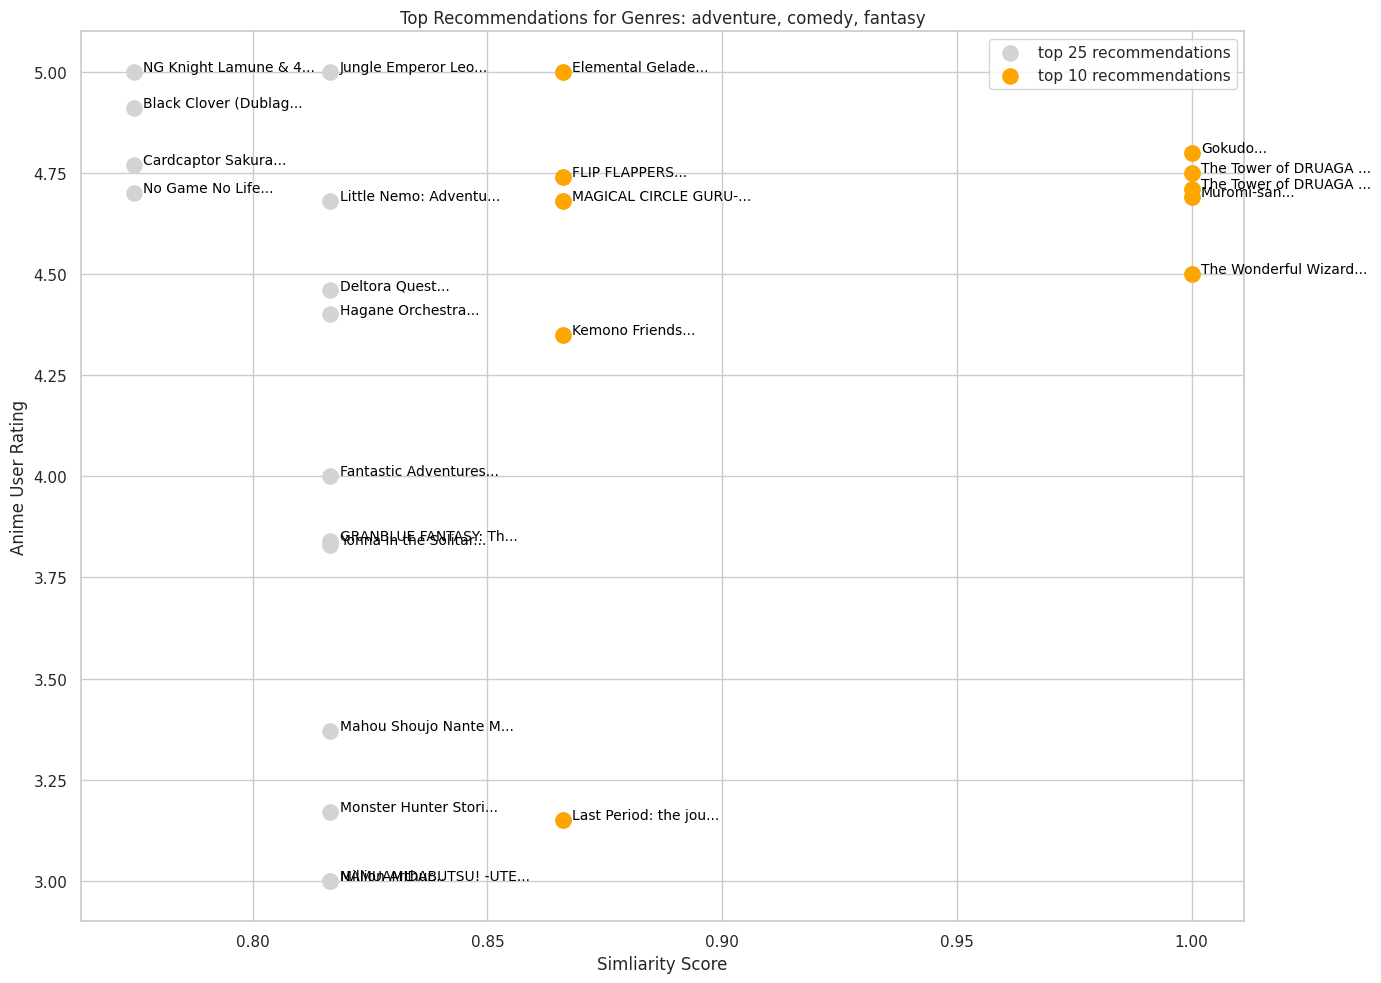

In [ ]:
# Top 10 Recommendations Visualization

def scatter_plot_similarity_rate(recs25_df, recs10_df, selected_genres):
  plt.figure(figsize=(14, 10))

  plt.scatter(
      recs25_df["similarity"],
      recs25_df["rate"],
      s=120,
      color="lightgray",
      label = "top 25 recommendations",
  )
  plt.scatter(
      recs10_df["similarity"],
      recs10_df["rate"],
      s=120,
      color="orange",
      label = "top 10 recommendations",
  )

  for _, row in recs25_df.iterrows():
    plt.text(
        row["similarity"] + 0.002,
        row["rate"] + 0.002,
        row["anime"][:20] + "...",
        fontsize = 10,
        color = "black"
    )
  plt.xlabel("Simliarity Score")
  plt.ylabel("Anime User Rating")
  title_genres = ", ".join(selected_genres)
  plt.title(f"Top Recommendations for Genres: {title_genres}")
  plt.legend()
  plt.tight_layout()
  plt.show()


example_genres = ["adventure", "comedy", "fantasy"]
recs25 = recommend_by_genres(example_genres, top_n=25)
recs10 = recs25.head(10)
scatter_plot_similarity_rate(recs25, recs10, example_genres)
